**Import Library**

---



In [76]:
import sys
sys.executable
import transformers
print(transformers.__version__)
import torch
print(torch.backends.mps.is_available())
print(torch.backends.mps.is_built())
import accelerate
print(accelerate.__version__)

5.0.0
True
True
1.12.0


In [ ]:
import pandas as pd
from collections import Counter
import numpy as np
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score, classification_report)
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from wordcloud import WordCloud
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
import transformers
from transformers import BertTokenizer
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset
from transformers import BertForSequenceClassification
from transformers import Trainer, TrainingArguments

**PreProcessing**

---

In [78]:
df = pd.read_csv('youtube_reviews_sampleenglish_2025.csv')
df.head()

,review_id,user_name,userImage,review_description,rating,thumbs_up,reviewCreatedVersion,review_date,developer_response,developer_response_date,appVersion,review_date.1,month,year,source
0,29b06b39-ef79-4f1f-aeb7-17456fcdc646,Ashish Bista,https://play-lh.googleusercontent.com/a-/ALV-U...,"This app is trash, it pops up a ad every 5 sec...",1,0,19.50.42,2025-01-17 07:47:38,NaN,NaN,19.50.42,2025-01-17 07:47:38,1,2025,Google Play
1,c21b7039-9df9-4270-9a97-bb742a1e648d,Harshit Singh,https://play-lh.googleusercontent.com/a-/ALV-U...,New update is worst all videos are showing so ...,2,1,19.50.40,2025-01-08 16:24:55,NaN,NaN,19.50.40,2025-01-08 16:24:55,1,2025,Google Play
2,6816f08d-8122-4e35-98f7-e6d7a4d883bb,Debojit Hazarika,https://play-lh.googleusercontent.com/a/ACg8oc...,Everything nice but add was irretating,5,0,19.50.40,2025-01-02 12:58:38,NaN,NaN,19.50.40,2025-01-02 12:58:38,1,2025,Google Play
3,b70ebdbb-17bb-4bd4-afe9-a12c4338b851,Mini Vasanthakumar,https://play-lh.googleusercontent.com/a/ACg8oc...,I love it but o i hate the $3X side plus some ...,4,0,19.50.40,2025-01-06 10:41:17,NaN,NaN,19.50.40,2025-01-06 10:41:17,1,2025,Google Play
4,d9aeadda-bcd4-4e0d-9556-a1cadee646f7,Nadine Mukiri,https://play-lh.googleusercontent.com/a/ACg8oc...,First of all it's YouTube ads no biggie but we...,2,3,18.38.37,2025-01-05 20:59:26,NaN,NaN,18.38.37,2025-01-05 20:59:26,1,2025,Google Play


In [79]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   review_id                6000 non-null   str    
 1   user_name                6000 non-null   str    
 2   userImage                6000 non-null   str    
 3   review_description       6000 non-null   str    
 4   rating                   6000 non-null   int64  
 5   thumbs_up                6000 non-null   int64  
 6   reviewCreatedVersion     5889 non-null   str    
 7   review_date              6000 non-null   str    
 8   developer_response       0 non-null      float64
 9   developer_response_date  0 non-null      float64
 10  appVersion               5889 non-null   str    
 11  review_date.1            6000 non-null   str    
 12  month                    6000 non-null   int64  
 13  year                     6000 non-null   int64  
 14  source                   6000 non-n

In [80]:
df = df[[
    'review_description',
    'rating',
    'review_date',
    'month',
    'year'
]]

In [81]:
df.head()

,review_description,rating,review_date,month,year
0,"This app is trash, it pops up a ad every 5 sec...",1,2025-01-17 07:47:38,1,2025
1,New update is worst all videos are showing so ...,2,2025-01-08 16:24:55,1,2025
2,Everything nice but add was irretating,5,2025-01-02 12:58:38,1,2025
3,I love it but o i hate the $3X side plus some ...,4,2025-01-06 10:41:17,1,2025
4,First of all it's YouTube ads no biggie but we...,2,2025-01-05 20:59:26,1,2025


In [82]:
def clean_text(text):
    text = text.lower() # Mengubah text menjadi huruf kecil
    text = re.sub(r"http\S+", "", text) # Menghapus URL
    text = re.sub(r"\s+", " ", text).strip() # Menghapus spasi yang berlebih
    text = re.sub(r"[^a-z\s]", "", text)         #  menghapus angka & simbol
    text =  re.sub(r'\b(?!i\b|a\b)[a-zA-Z]\b', '', text)  # hapus token 1 huruf kecuali "i" dan "a"

    return text

df['review_description'] = df['review_description'].apply(clean_text)

In [83]:
df.head()

,review_description,rating,review_date,month,year
0,this app is trash it pops up a ad every sec a...,1,2025-01-17 07:47:38,1,2025
1,new update is worst all videos are showing so ...,2,2025-01-08 16:24:55,1,2025
2,everything nice but add was irretating,5,2025-01-02 12:58:38,1,2025
3,i love it but i hate the side plus some of t...,4,2025-01-06 10:41:17,1,2025
4,first of all its youtube ads no biggie but we ...,2,2025-01-05 20:59:26,1,2025


In [84]:
# Melakukan tokenizing
df['tokens'] = df['review_description'].apply(lambda x: x.split())

In [85]:
# Remove stopwords seperti a, the, is, are
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

df['tokens'] = df['tokens'].apply(
    lambda x: [word for word in x if word not in stop_words]
)

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/wilbert/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [86]:
df.head()

,review_description,rating,review_date,month,year,tokens
0,this app is trash it pops up a ad every sec a...,1,2025-01-17 07:47:38,1,2025,"[app, trash, pops, ad, every, sec, cant, even,..."
1,new update is worst all videos are showing so ...,2,2025-01-08 16:24:55,1,2025,"[new, update, worst, videos, showing, small, l..."
2,everything nice but add was irretating,5,2025-01-02 12:58:38,1,2025,"[everything, nice, add, irretating]"
3,i love it but i hate the side plus some of t...,4,2025-01-06 10:41:17,1,2025,"[love, hate, side, plus, toxic, community, reg..."
4,first of all its youtube ads no biggie but we ...,2,2025-01-05 20:59:26,1,2025,"[first, youtube, ads, biggie, didnt, ask, many..."


In [87]:
# Melakukan lemmatizing
# Menghapus kata plural menjadi singular contoh books -> book

nltk.download('wordnet')

lemmatizer = WordNetLemmatizer()

def lemmatize_tokens(tokens):
    return [lemmatizer.lemmatize(word) for word in tokens]

df['tokens'] = df['tokens'].apply(lemmatize_tokens)

[nltk_data] Downloading package wordnet to /Users/wilbert/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [88]:
df.head()

,review_description,rating,review_date,month,year,tokens
0,this app is trash it pops up a ad every sec a...,1,2025-01-17 07:47:38,1,2025,"[app, trash, pop, ad, every, sec, cant, even, ..."
1,new update is worst all videos are showing so ...,2,2025-01-08 16:24:55,1,2025,"[new, update, worst, video, showing, small, li..."
2,everything nice but add was irretating,5,2025-01-02 12:58:38,1,2025,"[everything, nice, add, irretating]"
3,i love it but i hate the side plus some of t...,4,2025-01-06 10:41:17,1,2025,"[love, hate, side, plus, toxic, community, reg..."
4,first of all its youtube ads no biggie but we ...,2,2025-01-05 20:59:26,1,2025,"[first, youtube, ad, biggie, didnt, ask, many,..."


In [89]:
remove_words = {'app', 'youtube', 'channel', 'video', 'tube'}

df['tokens'] = df['tokens'].apply(
    lambda tokens: [w for w in tokens if w not in remove_words]
)

df['review_description'] = df['tokens'].apply(lambda x: " ".join(x))
# df = df.drop(columns=['tokens'])

df.head()

,review_description,rating,review_date,month,year,tokens
0,trash pop ad every sec cant even watch single ...,1,2025-01-17 07:47:38,1,2025,"[trash, pop, ad, every, sec, cant, even, watch..."
1,new update worst showing small like downloads,2,2025-01-08 16:24:55,1,2025,"[new, update, worst, showing, small, like, dow..."
2,everything nice add irretating,5,2025-01-02 12:58:38,1,2025,"[everything, nice, add, irretating]"
3,love hate side plus toxic community regard mini,4,2025-01-06 10:41:17,1,2025,"[love, hate, side, plus, toxic, community, reg..."
4,first ad biggie didnt ask many ad annoying thi...,2,2025-01-05 20:59:26,1,2025,"[first, ad, biggie, didnt, ask, many, ad, anno..."


**Labeling**

---



In [90]:
def label_sentiment(rating):
    if rating <= 3:
        return 0   # negatif
    else:
        return 1   # positif

df['label'] = df['rating'].apply(label_sentiment)

In [91]:
df.head()

,review_description,rating,review_date,month,year,tokens,label
0,trash pop ad every sec cant even watch single ...,1,2025-01-17 07:47:38,1,2025,"[trash, pop, ad, every, sec, cant, even, watch...",0
1,new update worst showing small like downloads,2,2025-01-08 16:24:55,1,2025,"[new, update, worst, showing, small, like, dow...",0
2,everything nice add irretating,5,2025-01-02 12:58:38,1,2025,"[everything, nice, add, irretating]",1
3,love hate side plus toxic community regard mini,4,2025-01-06 10:41:17,1,2025,"[love, hate, side, plus, toxic, community, reg...",1
4,first ad biggie didnt ask many ad annoying thi...,2,2025-01-05 20:59:26,1,2025,"[first, ad, biggie, didnt, ask, many, ad, anno...",0


In [92]:
df['label'].value_counts(normalize=True) * 100

label
0    56.633333
1    43.366667
Name: proportion, dtype: float64

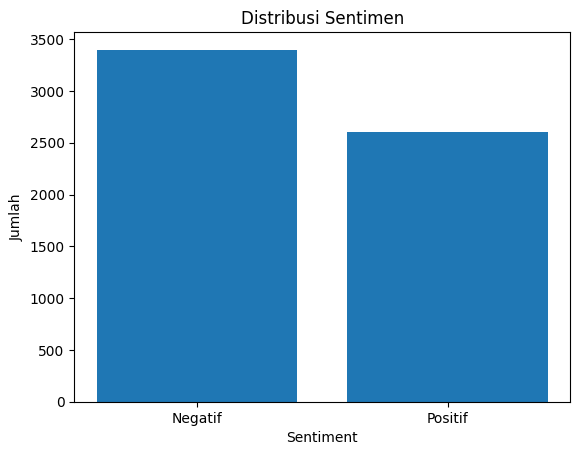

In [93]:
label_counts = df['label'].value_counts().sort_index()

# Buat bar chart
plt.figure()
plt.bar(label_counts.index, label_counts.values)

# Ubah angka label jadi teks agar lebih jelas
plt.xticks([0, 1], ['Negatif', 'Positif'])

plt.xlabel('Sentiment')
plt.ylabel('Jumlah')
plt.title('Distribusi Sentimen')
plt.show()

**Word Cloud**

---


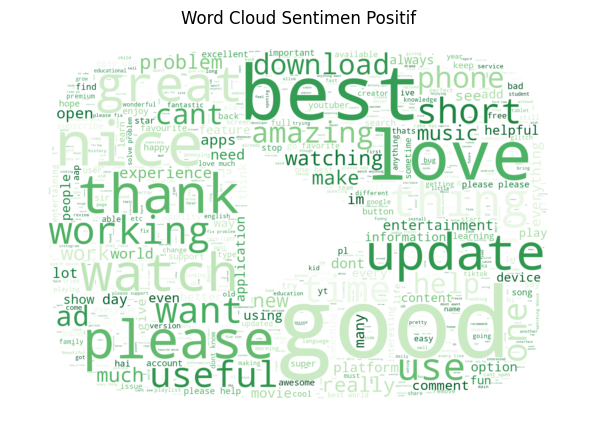

In [101]:
text_pos = " ".join(df[df['label'] == 1]['review_description'])

mask = np.array(Image.open('./images/youtube_logo.png'))

wc_pos = WordCloud(
    background_color="white",
    colormap="Greens",
    mask=mask,
    max_words = 2000,
    max_font_size = 500,
    random_state = 42, 
    width = mask.shape[1],
    height = mask.shape[0],
).generate(text_pos)

plt.figure(figsize=(10,5))
plt.imshow(wc_pos, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud Sentimen Positif")
plt.show()

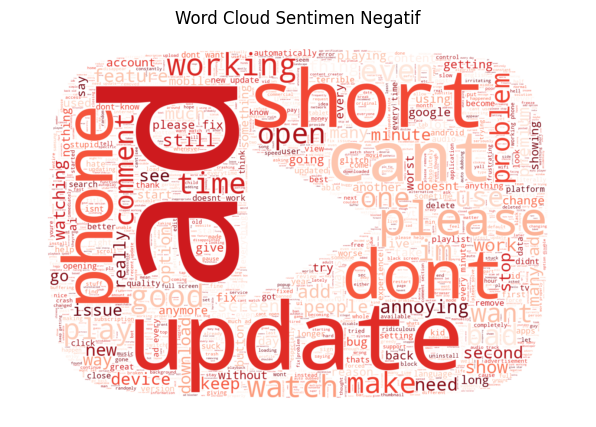

In [102]:
text_neg = " ".join(df[df['label'] == 0]['review_description'])

wc_neg = WordCloud(
   background_color="white",
    colormap="Reds",
    mask=mask,
    max_words = 2000,
    max_font_size = 500,
    random_state = 42, 
    width = mask.shape[1],
    height = mask.shape[0],
).generate(text_neg)

plt.figure(figsize=(10,5))
plt.imshow(wc_neg, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud Sentimen Negatif")
plt.show()

**Stacked BarChart**

---


In [62]:
# Pisahkan teks
positive_text = " ".join(df[df['label'] == 1]['review_description'])
negative_text = " ".join(df[df['label'] == 0]['review_description'])

# Tokenisasi
pos_words = positive_text.split()
neg_words = negative_text.split()

# Hitung frekuensi
pos_freq = Counter(pos_words)
neg_freq = Counter(neg_words)

In [63]:
all_words = pos_words + neg_words
top_words = [word for word, _ in Counter(all_words).most_common(10)]
print(top_words)

['ad', 'good', 'update', 'please', 'like', 'cant', 'short', 'watch', 'dont', 'time']


In [64]:
data = []

for word in top_words:
    data.append({
        'word': word,
        'positive': pos_freq[word],
        'negative': neg_freq[word]
    })

df_plot = pd.DataFrame(data)

In [65]:
df_plot.head(10)

,word,positive,negative
0,ad,78,1073
1,good,488,216
2,update,114,584
3,please,266,397
4,like,216,346
5,cant,96,416
6,short,84,374
7,watch,147,289
8,dont,81,340
9,time,118,301


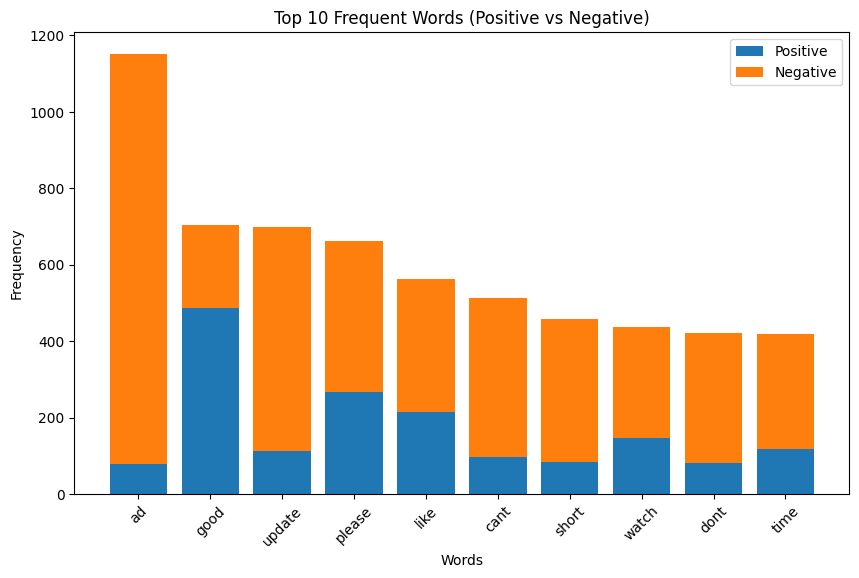

In [66]:
plt.figure(figsize=(10,6))

plt.bar(df_plot['word'], df_plot['positive'], label='Positive')
plt.bar(df_plot['word'], df_plot['negative'],
        bottom=df_plot['positive'], label='Negative')

plt.title("Top 10 Frequent Words (Positive vs Negative)")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.legend()

plt.show()

In [68]:
filtered_df = df[df['review_description'].str.contains(r'\bad\b', case=False, regex=True)]
filtered_df['sentiment'] = df['label'].map({0: 'negative', 1: 'positive'})

In [75]:
result_df = filtered_df[['review_description', 'sentiment']]
result_df.sample(10)

,review_description,sentiment
4970,many ad hassle get rid even ad completed playi...,negative
1975,im neurodivergent highly dependent subtitle sp...,negative
4306,one decade ago fun barely ad like im watching ...,negative
4354,ive always loved many thing watch many differe...,negative
127,disgusted even complaining frequency ad show f...,negative
5169,nobody want see ad stop ruin moment flow frequ...,negative
3114,getting extremely bad ad ad longer im trying w...,negative
4280,glitch absolutely terrible watch advert watch ...,negative
5561,bad many ad,negative
4515,plagued useless ad dont premium,negative


In [ ]:
# result_df.to_csv('reviews_with_ad.csv', index=False)

In [24]:
# 80% train, 10% validation, 10% test
X_train, X_temp, y_train, y_temp = train_test_split(
    df['review_description'],
    df['label'],
    test_size=0.2,
    stratify=df['label'],
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    stratify=y_temp,
    random_state=42
)

**BERT Tokenizer**

---



In [25]:
# mengubah teks ulasan menjadi representasi numerik yang dapat diproses oleh model BERT.
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

def tokenize(texts):
    return tokenizer(
        list(texts),
        padding=True,
        truncation=True,
        max_length=128,
        return_tensors="pt"
    )

train_enc = tokenize(X_train)
val_enc   = tokenize(X_val)
test_enc  = tokenize(X_test)

In [26]:
# Buat Dataset PyTorch
# membungkus hasil tokenisasi dan label ke dalam format dataset PyTorch agar dapat digunakan oleh model BERT 
# saat proses training dan evaluasi.
class ReviewDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels.values

    def __getitem__(self, idx):
        item = {k: v[idx] for k, v in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

train_ds = ReviewDataset(train_enc, y_train)
val_ds   = ReviewDataset(val_enc, y_val)
test_ds  = ReviewDataset(test_enc, y_test)

In [27]:
# Load Model untuk classifier / Set Up Pretrain
model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=2
)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 1386.37it/s, Materializing param=bert.pooler.dense.weight]                               
BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those p

**Fine Tuning**

---



In [28]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)

    return {
        "accuracy": accuracy_score(labels, preds),
        "precision": precision_score(labels, preds),
        "recall": recall_score(labels, preds),
        "f1": f1_score(labels, preds)
    }

# Optimizer dan scheduler cth: learning rate, batch size, num_epoch
training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    logging_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    logging_dir="./logs"
)

# Data Loader
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    compute_metrics=compute_metrics

)

# Fine Tuning
trainer.train()

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.
/Users/wilbert/Documents/Skripsi/Coding_DataScience/venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.480570,0.435740,0.821667,0.797665,0.788462,0.793037
2,0.365958,0.467930,0.815000,0.806584,0.753846,0.779324
3,0.294869,0.491883,0.800000,0.757353,0.792308,0.774436


/Users/wilbert/Documents/Skripsi/Coding_DataScience/venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.69it/s]
/Users/wilbert/Documents/Skripsi/Coding_DataScience/venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
/Users/wilbert/Documents/Skripsi/Coding_DataScience/venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.60it/s]
/Users/wilbert/Documents/Skripsi/Coding_DataScience/venv/lib/python3.

TrainOutput(global_step=900, training_loss=0.38046573215060764, metrics={'train_runtime': 355.4174, 'train_samples_per_second': 40.516, 'train_steps_per_second': 2.532, 'total_flos': 665999858880000.0, 'train_loss': 0.38046573215060764, 'epoch': 3.0})

In [29]:
trainer.state.log_history

[{'loss': 0.4805702718098958,
  'grad_norm': 4.47743558883667,
  'learning_rate': 1.3355555555555557e-05,
  'epoch': 1.0,
  'step': 300},
 {'eval_loss': 0.4357399642467499,
  'eval_accuracy': 0.8216666666666667,
  'eval_precision': 0.7976653696498055,
  'eval_recall': 0.7884615384615384,
  'eval_f1': 0.793036750483559,
  'eval_runtime': 2.7097,
  'eval_samples_per_second': 221.424,
  'eval_steps_per_second': 14.024,
  'epoch': 1.0,
  'step': 300},
 {'loss': 0.3659577178955078,
  'grad_norm': 6.740721702575684,
  'learning_rate': 6.688888888888889e-06,
  'epoch': 2.0,
  'step': 600},
 {'eval_loss': 0.4679301977157593,
  'eval_accuracy': 0.815,
  'eval_precision': 0.8065843621399177,
  'eval_recall': 0.7538461538461538,
  'eval_f1': 0.7793240556660039,
  'eval_runtime': 2.602,
  'eval_samples_per_second': 230.593,
  'eval_steps_per_second': 14.604,
  'epoch': 2.0,
  'step': 600},
 {'loss': 0.29486920674641925,
  'grad_norm': 7.718326091766357,
  'learning_rate': 2.2222222222222224e-08,
 

In [30]:
log_history = trainer.state.log_history

train_epochs = []
train_losses = []

val_epochs = []
val_losses = []

for log in trainer.state.log_history:
    if "loss" in log and "epoch" in log:
        train_epochs.append(log["epoch"])
        train_losses.append(log["loss"])
    if "eval_loss" in log and "epoch" in log:
        val_epochs.append(log["epoch"])
        val_losses.append(log["eval_loss"])

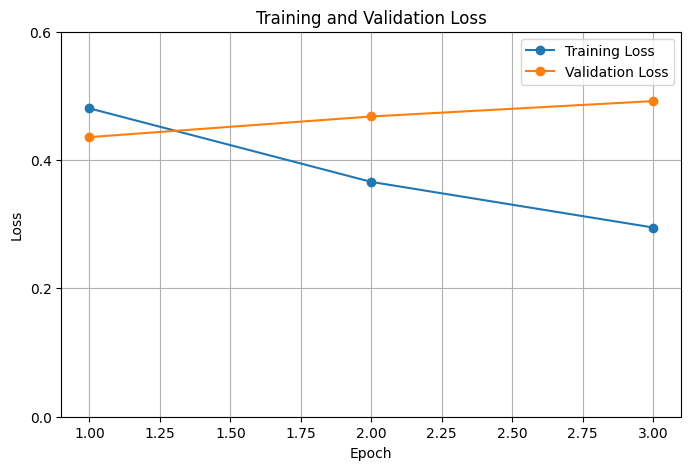

In [31]:
plt.figure(figsize=(8,5))

plt.plot(train_epochs, train_losses, marker="o", label="Training Loss")
plt.plot(val_epochs, val_losses, marker="o", label="Validation Loss")
plt.yticks(np.arange(0, 0.7, 0.2))
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

**Evaluation**

---



/Users/wilbert/Documents/Skripsi/Coding_DataScience/venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


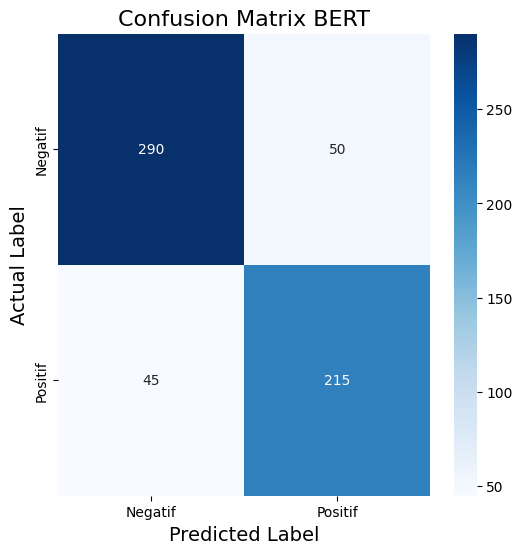

In [32]:
pred = trainer.predict(test_ds)
y_pred = pred.predictions.argmax(axis=1)

conf_matrix = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 6))
sns.heatmap(
    conf_matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Negatif", "Positif"],
    yticklabels=["Negatif", "Positif"]
)

plt.title("Confusion Matrix BERT", fontsize=16)
plt.xlabel("Predicted Label", fontsize=14)
plt.ylabel("Actual Label", fontsize=14)
plt.show()

In [33]:
pred = trainer.predict(test_ds)
y_pred = pred.predictions.argmax(axis=1)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred))

/Users/wilbert/Documents/Skripsi/Coding_DataScience/venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Accuracy: 0.8416666666666667
Precision: 0.8113207547169812
Recall   : 0.8269230769230769
F1-score: 0.819047619047619


In [34]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.87      0.85      0.86       340
           1       0.81      0.83      0.82       260

    accuracy                           0.84       600
   macro avg       0.84      0.84      0.84       600
weighted avg       0.84      0.84      0.84       600



**Predict Setniment**

---

In [36]:
# set device (WAJIB)
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
model.to(device)

def predict_sentiment(text):
    # preprocessing ringan (konsisten dengan training)
    text = text.lower()
    
    # tokenisasi
    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128
    )
    
    # pindahkan ke device yang sama
    inputs = {k: v.to(device) for k, v in inputs.items()}
    
    # prediksi
    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits

        probs = F.softmax(logits, dim=1)   # ubah logits → probabilitas
        prediction = torch.argmax(probs, dim=1).item()
        confidence = probs[0][prediction].item()
    
    # mapping label
    label_map = {0: "Negative", 1: "Positive"}
    return label_map[prediction], confidence * 100

In [37]:
label, confidence = predict_sentiment("Youtube is made me insane")
print(f"Sentiment: {label}")
print(f"Confidence: {confidence:.2f}%")

Sentiment: Negative
Confidence: 76.82%


In [62]:
save_dir = "./bert_youtube_sentiment"

model.save_pretrained(save_dir)
tokenizer.save_pretrained(save_dir)

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.57it/s]


('./bert_youtube_sentiment/tokenizer_config.json',
 './bert_youtube_sentiment/tokenizer.json')